In [113]:
from dotenv import load_dotenv

In [114]:
load_dotenv()

True

In [115]:
import os
from langgraph.graph import START,END,StateGraph
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage,HumanMessage
from pydantic import BaseModel,Field 

In [116]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [117]:
class State(TypedDict):
    application : str
    experience :str
    skill_match :str
    response :str



In [118]:
workflow = StateGraph(State)

In [128]:
def categorize_experience(State):
    print("Categorizing the experience level")
    prompt = ChatPromptTemplate.from_template(
        "Based on the following job application ,categorize the candidate as 'Entry-Level','Mid-Level' or 'Senior-level'"
        "Application:{application}"
    )

    chain = prompt | llm 
    experience_level = chain.invoke({"application":State["application"]}).content
    print(f"Experience Level : {experience_level}")
    return {"experience_level":experience_level}

def assess_skill(State):
    print("Accessing the skillset of the candidate")
    prompt = ChatPromptTemplate.from_template("Based on the job application for a python developer, asses the candidate's skillset"
    "Respond with either 'Match or 'No Match"
    "Application:{application}"
    )

    chain = prompt | llm
    skill_match=chain.invoke({"application":State["application"]}).content
    print(f"Skill Match:{skill_match}") 
    return {"skill Match":skill_match}


def schedule_interview(State):
    print("Interview being Scheduled:")
    return {"response":"Candidate has been shortlisted for an HR interview"}

def progress(State):
    print("Directly sent to recruiter")
    return {"response":"Candidate has senior-level experience but doesnt match Job skills"}

def rejection(State):
    print("Application has been rejected")
    return {"response":"Candidate doesn't meet Jod Description and has been rejected"}    



In [120]:
workflow.add_node("categorize_experience",categorize_experience)
workflow.add_node("assess_skill",assess_skill)
workflow.add_node("schedule_interview",schedule_interview)
workflow.add_node("progress",progress)
workflow.add_node("rejection",rejection)



In [121]:
def route(State):
    if (State['skill_match'] == "Match"):
        return "schedule_interview"
    elif (State['skill_match']=="Senior-Level"):
        return "progress" 
    else:
        return "rejection"



In [122]:
workflow.add_edge(START,"categorize_experience")
workflow.add_edge("categorize_experience","assess_skill")
workflow.add_conditional_edges("assess_skill",route,{
        "schedule_interview": "schedule_interview",
        "progress": "progress",
        "rejection": "rejection"})
workflow.add_edge("schedule_interview",END)
workflow.add_edge("progress",END)
workflow.add_edge("rejection",END)

In [123]:
graph=workflow.compile()

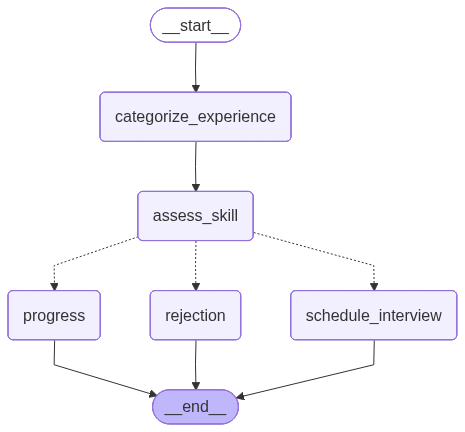

In [124]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [125]:
def run(application:str):
    results=graph.invoke({"application":application})
    return {"experience_level": results["experience_level"],
    "skill_match":results["skill_match"],"response": results["response"]}
   


In [129]:
application_text="I have 10 years experience in C++ Roles and in Software Engineering"
results=run(application_text)
print(f"application:{application_text}")
print(f"Expereince Level:{results['experience_level']}")
print(f"Skill match:{results['skill_match']}")
print(f"Response:{results['response']}")

Categorizing the experience level
Experience Level : Based on the information provided, the candidate would be categorized as **Senior-Level**.

**Reasoning:**

*   **10 years of experience** is well beyond the typical range for Entry-Level (0-2 years) or Mid-Level (3-7 years) positions in software engineering.
*   "C++ Roles and in Software Engineering" indicates direct, relevant experience in the field.
Accessing the skillset of the candidate
Skill Match:No Match


KeyError: 'skill_match'